In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

{'mutually_orthogonal': {('mutually_orthogonal', 0): [2.305526955653045, 2.2882428209660417, 2.0927550287569985, 1.4858265286785062, 1.1730856329707775, 1.0853558031179138, 0.9930073891655874, 0.917517672150822, 0.8328498086686862, 0.7851815526768312, 0.7365287380703425, 0.7138143202005807, 0.698975887338994, 0.6746476524967259, 0.6698613217321493, 0.6552303948644864, 0.6508710838980594, 0.644827337588294, 0.6399632742849447, 0.6457621930009227, 0.6068216521861189, 0.6036664287922746, 0.6067177956387148, 0.593430748430349, 0.5847706663406501, 0.5818117978209156, 0.5650190256409726, 0.5504968322939792, 0.5567223758010541, 0.5594374840542421, 0.5372902382228334, 0.5329093463340048], ('mutually_orthogonal', 1): [2.3051616054470254, 2.3061588295435502, 2.119830569978488, 1.5262147370031325, 1.159125128034818, 1.0262138944561199, 0.9497707253795559, 0.8742379152168662, 0.804930786965257, 0.7599791015608836, 0.7284846487691847, 0.708472452931485, 0.7032178953542547, 0.6894495588237957, 0.668

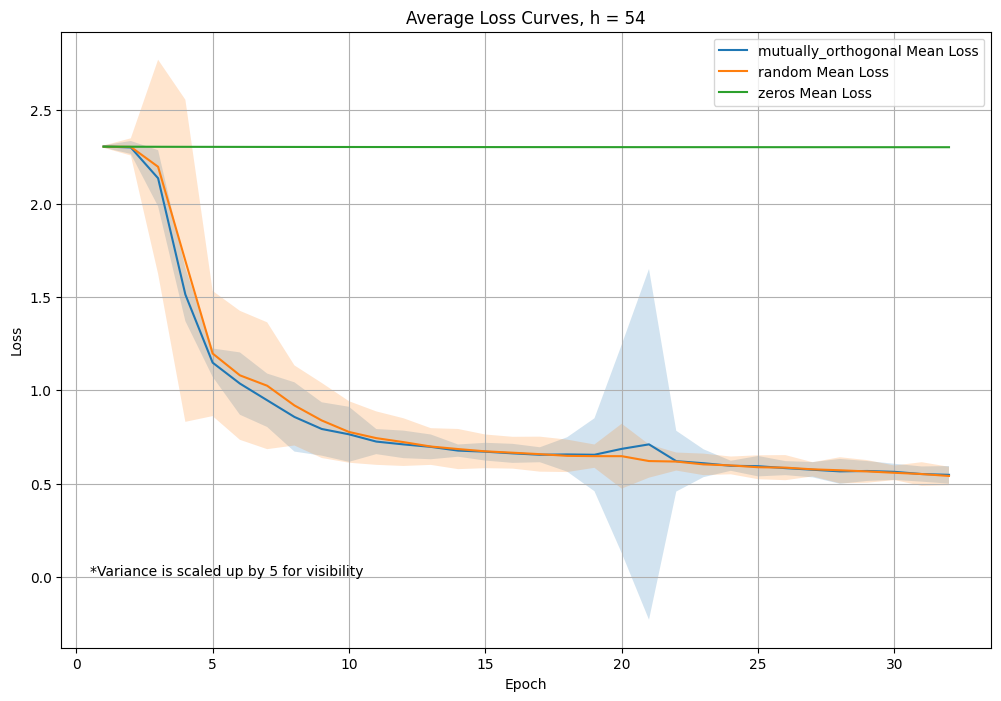

In [ ]:
# Replace this with the actual path to experiment results directory
experiment_output_dir = "path/to/final_project/output/experiment_results/"

# Modify which experiments show in the plot by adding or removing specific .pkl files to this list
data_paths = [os.path.join(experiment_output_dir, "h32_run_mutually_orthogonal_results.pkl"),
               os.path.join(experiment_output_dir, "h32_run_random_results.pkl"),
               # os.path.join(experiment_output_dir, "h32_run_random_identical_results.pkl"),
               os.path.join(experiment_output_dir, "h32_run_zeros_results.pkl")]

results = {}

for data_path in data_paths:
    with open(data_path, "rb") as f:
        strategy_name = data_path.split("/")[-1].split("_results.pkl")[0].split("h32_run_")[1]
        strategy_results = pickle.load(f)
        results[strategy_name] = strategy_results

print(results)
def plot_loss_curves_with_variance(results):
    losses_by_strategy = {}
    for strategy_name in results:
        for (strategy, run) in results[strategy_name]:
            losses = results[strategy_name][(strategy, run)]
            if strategy_name not in losses_by_strategy:
                losses_by_strategy[strategy_name] = []
            losses_by_strategy[strategy_name].append(losses)
    print(losses_by_strategy)
    plt.figure(figsize=(12, 8))
    for strategy_name, runs in losses_by_strategy.items():
        runs_array = np.array(runs)
        mean_loss = np.mean(runs_array, axis=0)
        print (mean_loss)
        std_loss = np.std(runs_array, axis=0)*5
        epochs = np.arange(1, mean_loss.size + 1)
        plt.plot(epochs, mean_loss, label=f"{strategy_name} Mean Loss")
        plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)
    plt.title("Average Loss Curves, h = 54")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.text(0.5, 0.01, "*Variance is scaled up by 5 for visibility")
    plt.grid()
    plt.show()

plot_loss_curves_with_variance(results)
        